In [1]:
# THIRANEX INTERNSHIP - PROJECT 1
# Data Cleaning and Visualization

print("Data Cleaning and Visualization Project")
print("Thiranex Internship")

Data Cleaning and Visualization Project
Thiranex Internship


# Data Cleaning and Visualization

## Objective
The objective of this project is to clean, preprocess, analyze, and visualize a dataset using Python.

### Tasks Performed
- Load and understand the dataset
- Identify missing values
- Handle missing values
- Identify and remove duplicate records
- Detect outliers
- Perform data cleaning
- Create meaningful visualizations
- Analyze relationships between variables
- Generate insights from the data

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (891, 15)


In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# Display basic information about the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types and Missing Values:")
df.info()

Number of rows: 891
Number of columns: 15

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null

In [7]:
# Statistical summary of numerical columns
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Count missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Percentage of missing values:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [10]:
# Drop deck because most of its values are missing
df.drop(columns=['deck'], inplace=True)
print("Column 'deck' removed.")
print("New shape:", df.shape)

Column 'deck' removed.
New shape: (891, 14)


In [11]:
# Fill missing age values using the median
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
print("Missing age values after cleaning:", df['age'].isnull().sum())

Missing age values after cleaning: 0


In [12]:
# Fill missing categorical values using the mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
print("Missing embarked values:", df['embarked'].isnull().sum())
print("Missing embark_town values:", df['embark_town'].isnull().sum())

Missing embarked values: 0
Missing embark_town values: 0


In [13]:
# Verify that all missing values have been handled
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [14]:
# Check for duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 116


In [15]:
# Remove duplicate records
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (775, 14)


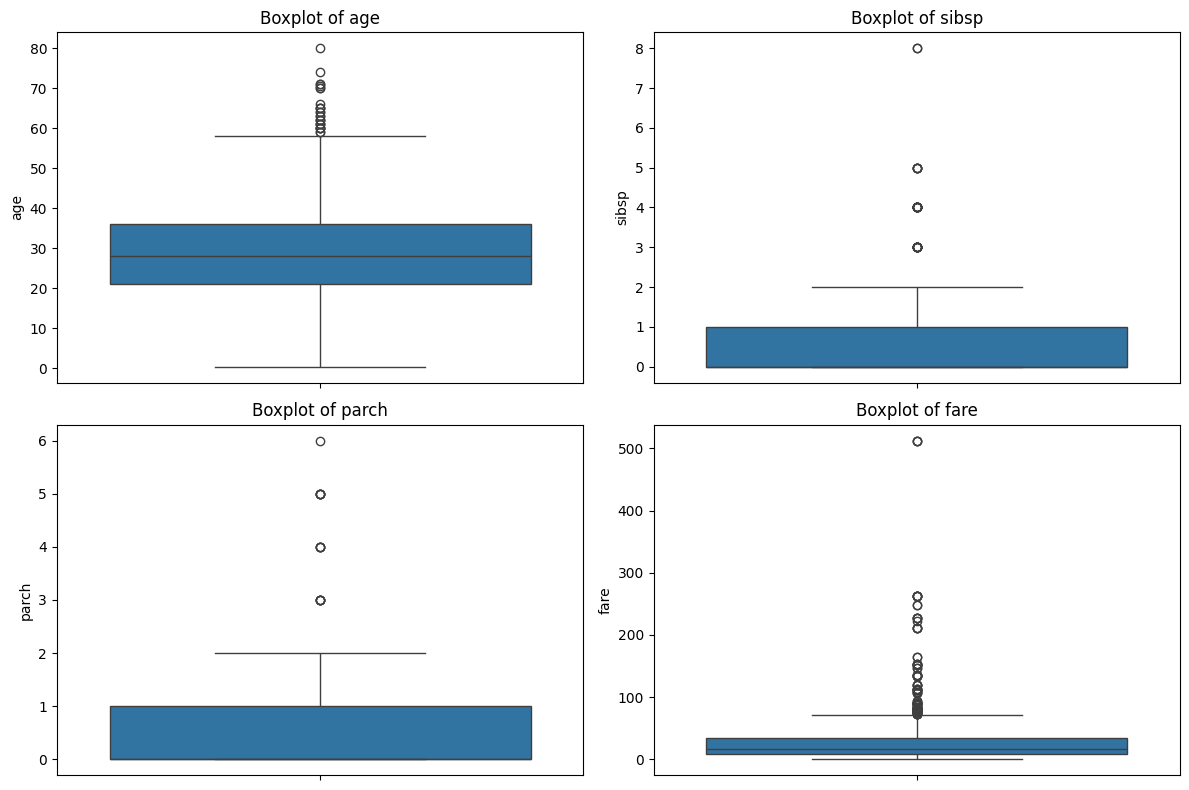

In [16]:
# Visualize numerical columns using boxplots
numerical_columns = ['age', 'sibsp', 'parch', 'fare']
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [17]:
# Detect outliers using the IQR method
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers")

age: 27 outliers
sibsp: 39 outliers
parch: 15 outliers
fare: 102 outliers


In [18]:
# Final check of the cleaned dataset
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())
print("\nDuplicate rows:")
print(df.duplicated().sum())

Final dataset shape: (775, 14)

Missing values:
0

Duplicate rows:
0


In [19]:
# Save the cleaned dataset
df.to_csv("cleaned_titanic_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


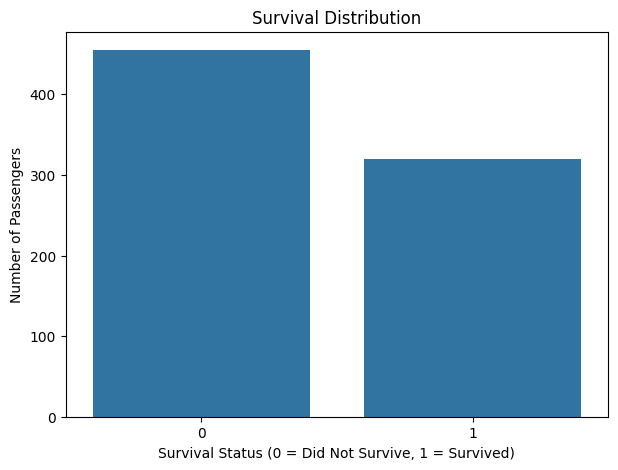

In [20]:
# Visualization 1: Survival Distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='survived', data=df)
plt.title('Survival Distribution')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.show()

### Observation

The survival distribution shows that the number of passengers who did not survive was higher than the number of passengers who survived. This indicates that survival was not evenly distributed among the passengers.

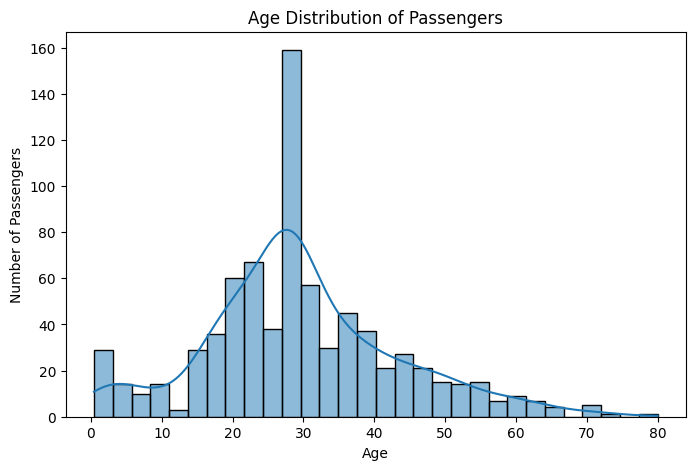

In [21]:
# Visualization 2: Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

### Observation

The age distribution shows that passengers were mainly concentrated in the young and middle-age groups. The distribution also indicates the presence of passengers across a wide range of ages.

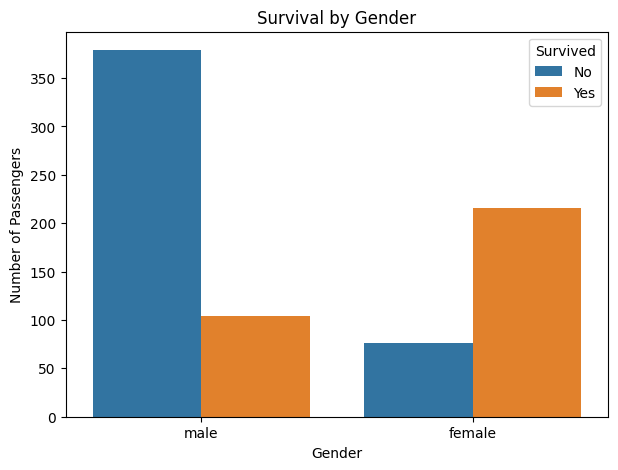

In [22]:
# Visualization 3: Gender vs Survival
plt.figure(figsize=(7, 5))
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### Observation

The visualization shows a clear difference in survival between male and female passengers. Female passengers had a substantially higher survival count compared with male passengers, while a large proportion of male passengers did not survive.

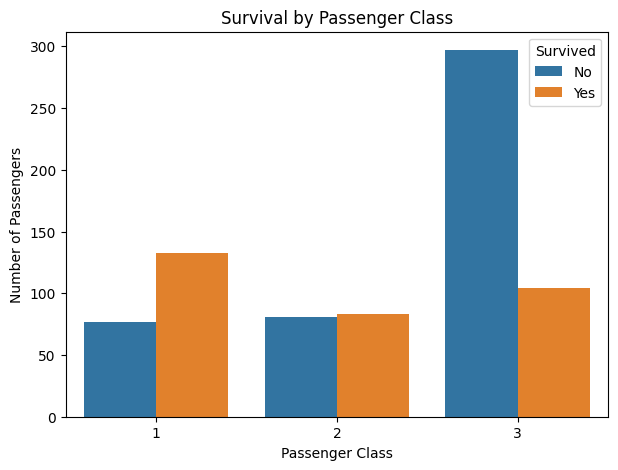

In [23]:
# Visualization 4: Passenger Class vs Survival
plt.figure(figsize=(7, 5))
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### Observation

The visualization indicates that passenger class was associated with survival. First-class passengers had a higher proportion of survivors, while third-class passengers had a larger number of non-survivors.

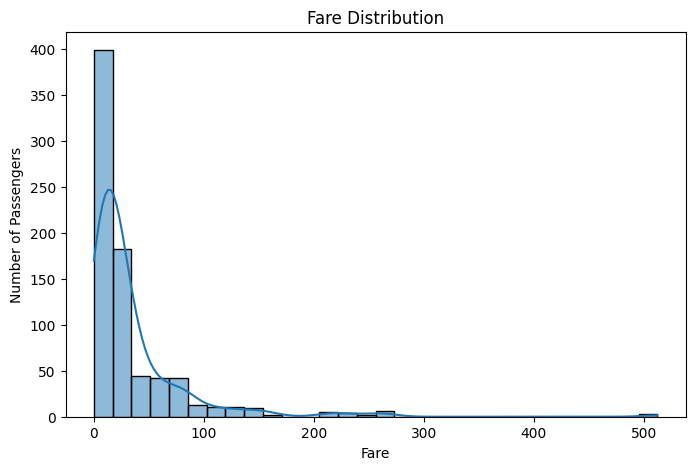

In [24]:
# Visualization 5: Fare Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.show()

### Observation

The fare distribution is right-skewed, with most passengers paying relatively lower fares and a smaller number of passengers paying substantially higher fares. These high fares correspond to the outliers identified during the data-cleaning stage.

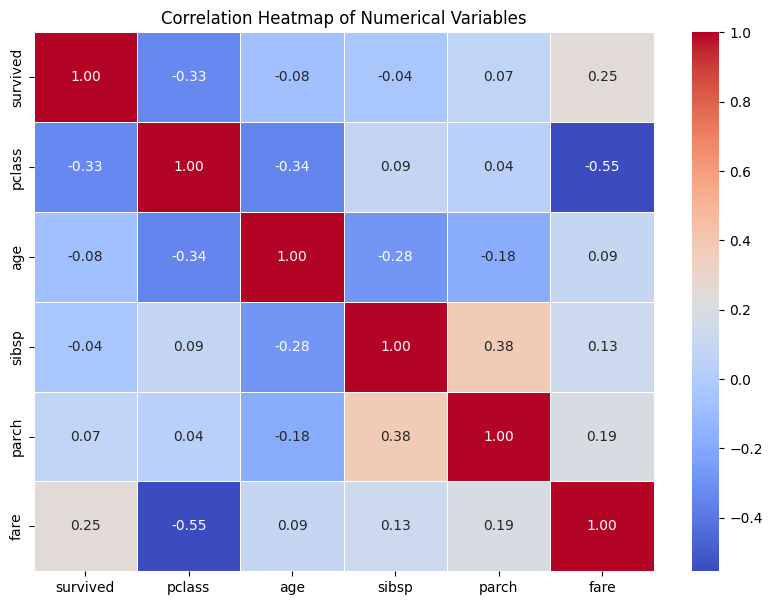

In [25]:
# Visualization 6: Correlation Heatmap
# Select numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# Calculate correlation
correlation = numeric_df.corr()
# Create heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Observation

The correlation heatmap shows the relationships between numerical variables in the dataset. Passenger class has a negative relationship with survival, indicating that passengers in lower-numbered classes generally had better survival outcomes. Fare also shows a relationship with passenger class and survival. Most other numerical variables have relatively weak correlations.

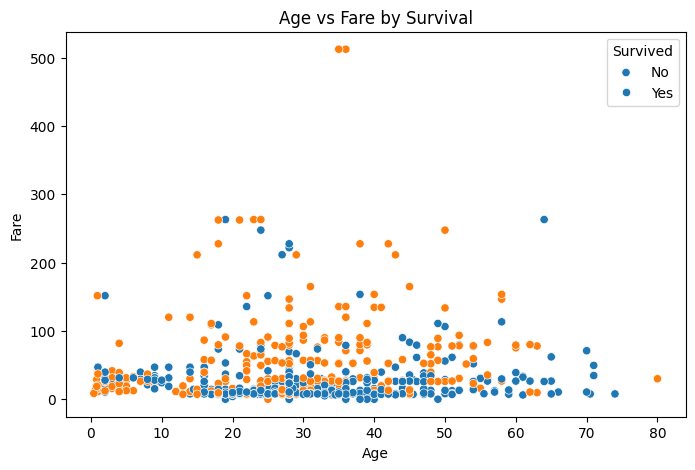

In [26]:
# Visualization 7: Age vs Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='age',
    y='fare',
    data=df,
    hue='survived'
)
plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### Observation

The scatter plot shows the relationship between passenger age and fare. There is no strong linear relationship between age and fare. However, passengers who paid higher fares are visible across different age groups, and survival outcomes vary among these passengers.

In [27]:
# Final overview of the cleaned dataset
print("FINAL DATASET SUMMARY")
print("-" * 30)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nColumns:")
print(df.columns.tolist())

FINAL DATASET SUMMARY
------------------------------
Rows: 775
Columns: 14
Missing values: 0
Duplicate rows: 0

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


# Key Findings

1. The original dataset contained 891 records and 15 columns.
2. The `deck` column was removed because approximately 77% of its values were missing.
3. Missing values in `age` were handled using the median.
4. Missing values in `embarked` and `embark_town` were handled using the mode.
5. A total of 116 duplicate records were identified and removed.
6. The final cleaned dataset contains 775 records and 14 columns.
7. Outliers were detected using the IQR method. The detected outliers were retained because they may represent valid passenger observations.
8. The survival distribution shows that more passengers did not survive than survived.
9. Female passengers had a substantially higher survival rate than male passengers.
10. Passenger class was strongly associated with survival, with first-class passengers generally having better survival outcomes.
11. Fare values were right-skewed, with a small number of passengers paying very high fares.
12. The correlation analysis showed that passenger class and fare had notable relationships with survival.

# Conclusion

The Titanic dataset was successfully cleaned, analyzed, and visualized using Python. Missing values and duplicate records were handled appropriately, while potential outliers were identified using statistical methods. Several visualizations were created to understand passenger characteristics and survival patterns.

The analysis indicates that factors such as gender, passenger class, and fare were associated with survival outcomes. The project demonstrates the complete data-cleaning and visualization workflow, from examining raw data to generating meaningful insights.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Final Dataset

Rows: 775  
Columns: 14  
Missing Values: 0  
Duplicate Rows: 0

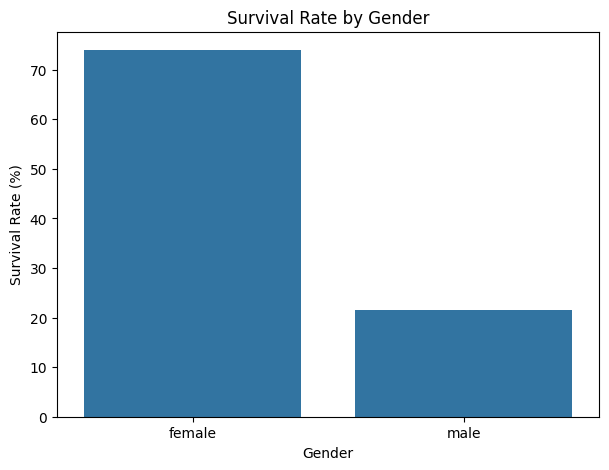

In [28]:
# Visualization 8: Survival Rate by Gender
survival_rate = df.groupby('sex')['survived'].mean() * 100
plt.figure(figsize=(7, 5))
sns.barplot(
    x=survival_rate.index,
    y=survival_rate.values
)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.show()

### Observation

The survival rate visualization clearly shows that female passengers had a considerably higher survival rate than male passengers in the dataset.